#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [ ]:
import pandas as pd

# Download dataset directly
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lesson_10_assignment.ipynb to Lesson_10_assignment.ipynb


In [ ]:
import os
print(os.listdir())

['.config', 'Lesson_10_assignment.ipynb', 'sample_data']


In [ ]:
'alexa_reviews.csv'

'alexa_reviews.csv'

In [ ]:
# Install (only first time)
!pip install -q scikit-learn seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
# Load dataset directly from internet (no upload needed)
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
# Keep only needed columns
df = df[['label', 'tweet']]

# Rename columns
df.columns = ['feedback', 'review']

# Convert label (0=positive, 1=negative → we flip it)
df['feedback'] = df['feedback'].apply(lambda x: 0 if x==1 else 1)

# Check data
df.head()

,feedback,review
0,1,@user when a father is dysfunctional and is s...
1,1,@user @user thanks for #lyft credit i can't us...
2,1,bihday your majesty
3,1,#model i love u take with u all the time in ...
4,1,factsguide: society now #motivation


In [ ]:
df.isnull().sum()

# Drop missing
df.dropna(inplace=True)

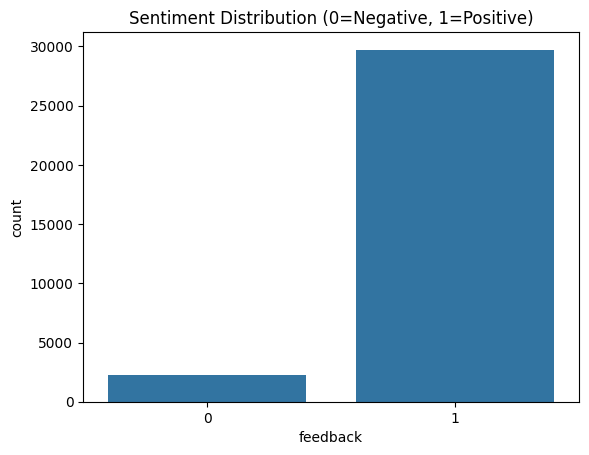

In [ ]:
sns.countplot(x='feedback', data=df)
plt.title("Sentiment Distribution (0=Negative, 1=Positive)")
plt.show()

In [ ]:
cv = CountVectorizer(stop_words='english', max_features=3000)

X = cv.fit_transform(df['review'])
y = df['feedback']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.79      0.46      0.58       456
           1       0.96      0.99      0.97      5937

    accuracy                           0.95      6393
   macro avg       0.88      0.72      0.78      6393
weighted avg       0.95      0.95      0.95      6393



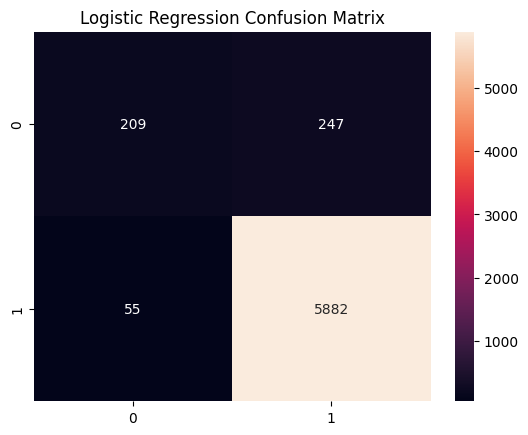


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.66      0.52      0.58       456
           1       0.96      0.98      0.97      5937

    accuracy                           0.95      6393
   macro avg       0.81      0.75      0.78      6393
weighted avg       0.94      0.95      0.94      6393



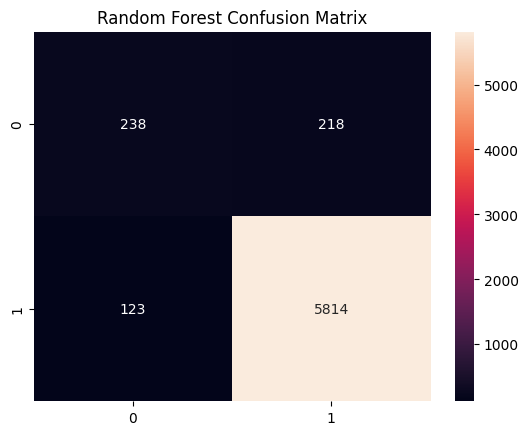


--- SVM ---
              precision    recall  f1-score   support

           0       0.91      0.37      0.53       456
           1       0.95      1.00      0.98      5937

    accuracy                           0.95      6393
   macro avg       0.93      0.68      0.75      6393
weighted avg       0.95      0.95      0.94      6393



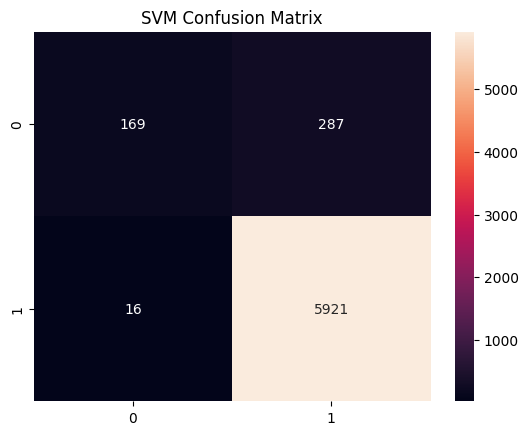

In [ ]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

# Evaluate all
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_svm, "SVM")

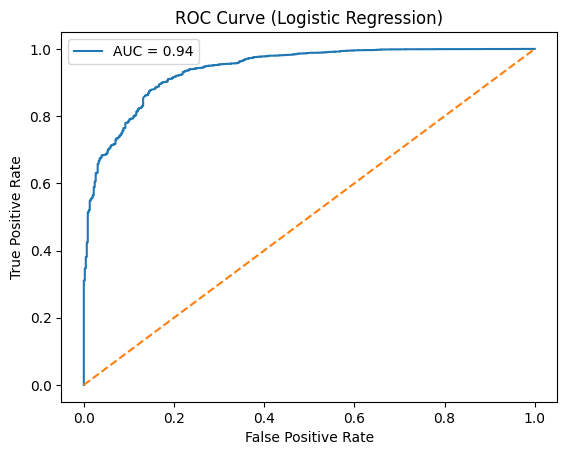

In [ ]:
# Logistic Regression ROC
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

In [ ]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

X_tfidf = tfidf.fit_transform(df['review'])

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.34      0.50       456
           1       0.95      1.00      0.97      5937

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.74      6393
weighted avg       0.95      0.95      0.94      6393



In [ ]:
param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


In [ ]:
def predict_sentiment(text):
    text_vec = tfidf.transform([text])
    pred = model.predict(text_vec)
    return "Positive 😊" if pred[0]==1 else "Negative 😞"

# Test
print(predict_sentiment("I love this product"))
print(predict_sentiment("This is very bad"))

Positive 😊
Positive 😊


In [ ]:
!pip install -q transformers

from transformers import pipeline

classifier = pipeline("sentiment-analysis")

print(classifier("I love this product"))
print(classifier("This is terrible"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998788833618164}]
[{'label': 'NEGATIVE', 'score': 0.9996459484100342}]
